<a href="https://colab.research.google.com/github/mdylanr/Muhammad-Dylan-Ramadhan/blob/main/%5BTRAINING_PSO%5D_SKRIPSI_DYLAN_UNTUK_TRAINING_HASIL_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model ini menggunakan **ResNet 50** dengan Optimasi Hyperparameter menggunakan **PSO** dataset yang digunakan dari Kaggle dengan 5 kelas. Data yang tidak seimbang diseimbangkan menggunakan **Random Oversampling**, pembagian dataset dibagi menjadi 3 bagian yaitu **Train, Validation dan Test** dengan Rasio 80:10:10. Hyperparameter yang dicari meliputi: **Learning Rate, Dropout Layers dan Batch Size**. Evaluasi model dilakukan menggunakan **Confusion Matrix**

---



Urutan yang Benar untuk Menjalankan Kode

Cell 4: Path Dataset - Menyiapkan direktori dan parameter.

Cell 5: Splitting Dataset - Membagi dataset menjadi train, validation, dan test.

Cell 6: Menghitung Class Weights - Menghitung bobot kelas berdasarkan distribusi data.

Cell 7: Persiapkan Data Generator - Mempersiapkan augmentasi data untuk training dan validation.

Cell 8: Definisi Model - Membangun arsitektur model (misalnya, ResNet50) dan mengatur kompilasi model.

Cell 10: Training Model Final - Menggunakan hyperparameter terbaik yang sudah Anda temukan dan melatih model.

In [1]:
# Cell 1: Setup Kaggle
!pip install kaggle
# !pip install pyswarms

# Create directory for Kaggle API token
!mkdir -p ~/.kaggle

# Upload your kaggle.json file
from google.colab import files
files.upload()  # Upload your kaggle.json here when prompted

# Move kaggle.json to the correct location
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
#@markdown Cell 2: Download and Extract Dataset
!kaggle datasets download -d warcoder/soyabean-seeds
!unzip soyabean-seeds.zip

Streaming output truncated to the last 5000 lines.
  inflating: Soybean Seeds/Broken soybeans/559.jpg  
  inflating: Soybean Seeds/Broken soybeans/56.jpg  
  inflating: Soybean Seeds/Broken soybeans/560.jpg  
  inflating: Soybean Seeds/Broken soybeans/561.jpg  
  inflating: Soybean Seeds/Broken soybeans/562.jpg  
  inflating: Soybean Seeds/Broken soybeans/563.jpg  
  inflating: Soybean Seeds/Broken soybeans/564.jpg  
  inflating: Soybean Seeds/Broken soybeans/565.jpg  
  inflating: Soybean Seeds/Broken soybeans/566.jpg  
  inflating: Soybean Seeds/Broken soybeans/567.jpg  
  inflating: Soybean Seeds/Broken soybeans/568.jpg  
  inflating: Soybean Seeds/Broken soybeans/569.jpg  
  inflating: Soybean Seeds/Broken soybeans/57.jpg  
  inflating: Soybean Seeds/Broken soybeans/570.jpg  
  inflating: Soybean Seeds/Broken soybeans/571.jpg  
  inflating: Soybean Seeds/Broken soybeans/572.jpg  
  inflating: Soybean Seeds/Broken soybeans/573.jpg  
  inflating: Soybean Seeds/Broken soybeans/574.jpg

In [3]:
# Cell 3: Import Libraries
# ============================

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import time
import math
import os
import shutil
print('All libraries are imported')

All libraries are imported


In [4]:
# Cell 4 Path Dataset
base_dir = '/content/Soybean Seeds'
working_dir = '/content/soybean_seeds_working'

# Label kelas
labels = ["Broken soybeans", "Immature soybeans", "Intact soybeans",
          "Skin-damaged soybeans", "Spotted soybeans"]

# Parameter model
IMG_SIZE = 224
EPOCHS = 30
NUM_CLASSES = 5

# Membuat direktori kerja
train_dir = os.path.join(working_dir, 'train')
validation_dir = os.path.join(working_dir, 'validation')
test_dir = os.path.join(working_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(validation_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print('Directories created successfully')

Directories created successfully


In [5]:
# Cell 5 Splitting Dataset
for label in labels:
    # Path ke folder label
    label_folder = os.path.join(base_dir, label)

    # Membuat subfolder train dan validation untuk masing-masing label
    label_train_dir = os.path.join(train_dir, label)
    label_val_dir = os.path.join(validation_dir, label)
    label_test_dir = os.path.join(test_dir, label)

    os.makedirs(label_train_dir, exist_ok=True)
    os.makedirs(label_val_dir, exist_ok=True)
    os.makedirs(label_test_dir, exist_ok=True)

    # Mendapatkan semua file gambar untuk label ini
    images = os.listdir(label_folder)

    # Membagi data menjadi train dan validation (80% train, 20% validation)
    # First split: Train and temp (80%/20%)
    train_images, temp_images = train_test_split(images, test_size=0.2, random_state=42)

    # Second split: Split temp into validation and test (50% of 20% = 10% each)
    val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)

    # Memindahkan gambar ke folder tujuan
    for image_name in train_images:
        shutil.copy(os.path.join(label_folder, image_name), os.path.join(label_train_dir, image_name))

    for image_name in val_images:
        shutil.copy(os.path.join(label_folder, image_name), os.path.join(label_val_dir, image_name))

# Add this line to copy test files
    for image_name in test_images:
        shutil.copy(os.path.join(label_folder, image_name), os.path.join(label_test_dir, image_name))

print("Dataset berhasil dibagi menjadi train, validation dan test.")

Dataset berhasil dibagi menjadi train, validation dan test.


In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

def compute_class_weights(train_dir, labels):
    class_counts = []
    for class_name in labels:
        class_dir = os.path.join(train_dir, class_name)
        if not os.path.isdir(class_dir):
            raise ValueError(f"Direktori kelas tidak ditemukan: {class_dir}")

        # Hitung jumlah file gambar
        count = sum(1 for _ in os.scandir(class_dir) if _.is_file())
        class_counts.append(count)

    # Cetak jumlah gambar di setiap kelas untuk debugging
    print("\nJumlah gambar per kelas:")
    for class_name, count in zip(labels, class_counts):
        print(f"{class_name}: {count}")

    # Buat array y yang berisi label untuk setiap gambar
    y = []
    for i, count in enumerate(class_counts):
        y.extend([i] * count)

    # Gunakan compute_class_weight dari sklearn
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y),
        y=np.array(y)
    )

    # Konversi ke dictionary
    class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

    print("\nClass Weights:")
    for cls, weight in class_weights_dict.items():
        print(f"Kelas {labels[cls]}: {weight:.2f}")

    return class_weights_dict

# Hitung class weights
class_weights = compute_class_weights(train_dir, labels)


Jumlah gambar per kelas:
Broken soybeans: 801
Immature soybeans: 900
Intact soybeans: 960
Skin-damaged soybeans: 901
Spotted soybeans: 846

Class Weights:
Kelas Broken soybeans: 1.10
Kelas Immature soybeans: 0.98
Kelas Intact soybeans: 0.92
Kelas Skin-damaged soybeans: 0.98
Kelas Spotted soybeans: 1.04


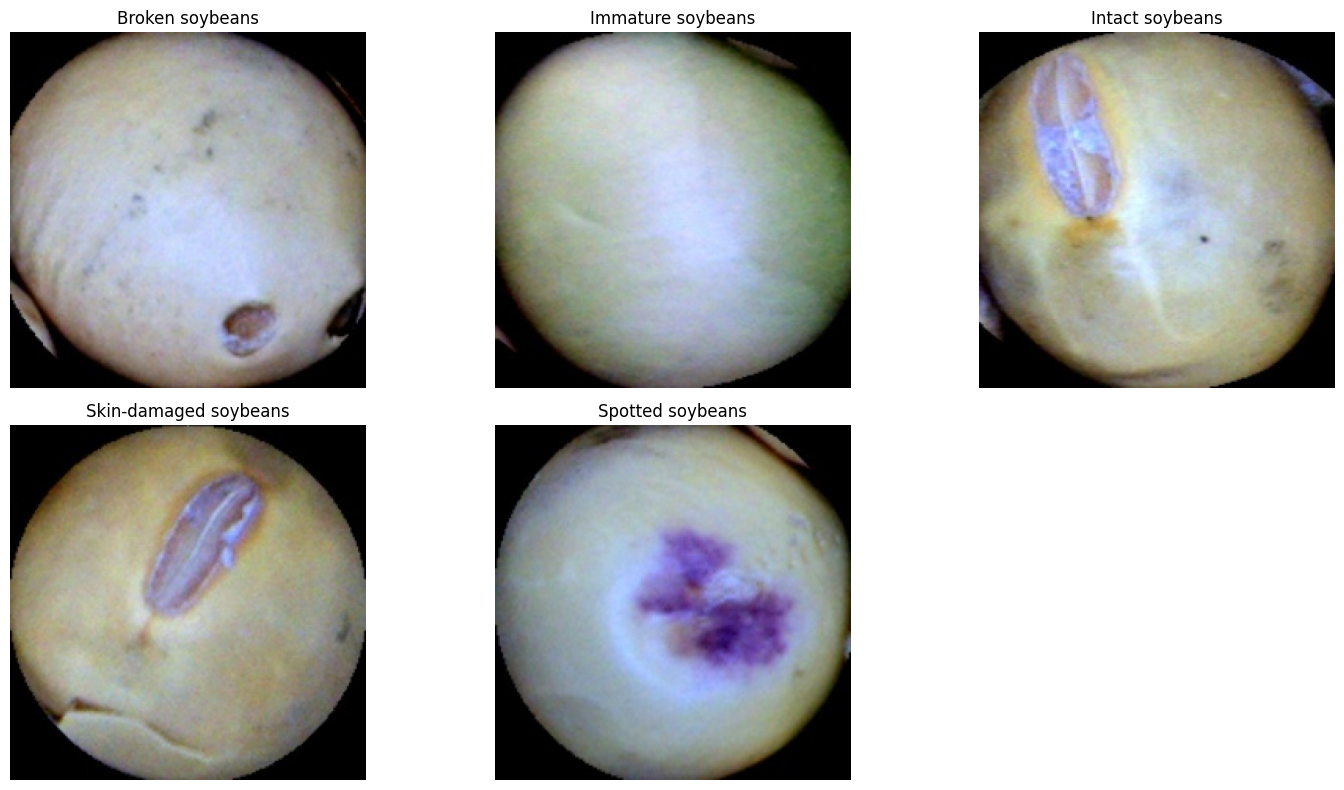

In [7]:
label_image_pairs = []
for label in labels:
    label_dir = os.path.join(test_dir, label)
    found = False
    for file in os.listdir(label_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(label_dir, file)
            label_image_pairs.append((label, img_path))
            found = True
            break
    if not found:
        print(f"[WARNING] Tidak ditemukan gambar di folder: {label_dir}")

# Tampilkan
cols = 3
rows = (len(label_image_pairs) + cols - 1) // cols
plt.figure(figsize=(5 * cols, 4 * rows))

for i, (label, img_path) in enumerate(label_image_pairs):
    img = Image.open(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
# Cell 7 Persiapkan Data Generator

# Augmentasi data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

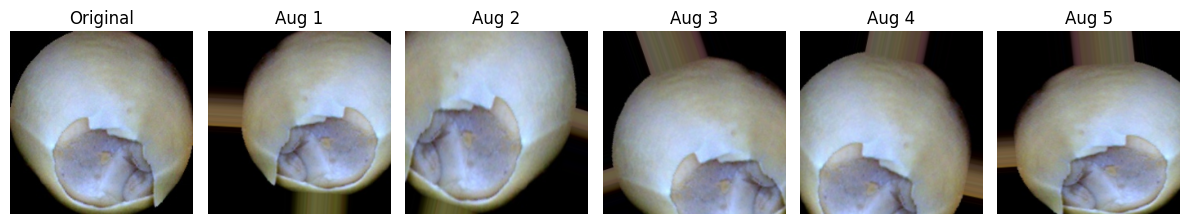

In [9]:
# Cell 8
from tensorflow.keras.preprocessing import image
# Ambil satu contoh gambar dari train_dir
example_class = labels[0]
example_dir = os.path.join(train_dir, example_class)
example_image_name = os.listdir(example_dir)[0]
example_image_path = os.path.join(example_dir, example_image_name)

# Load gambar asli
img = image.load_img(example_image_path, target_size=(IMG_SIZE, IMG_SIZE))
x = image.img_to_array(img)  # (224, 224, 3)
x = np.expand_dims(x, axis=0)  # (1, 224, 224, 3)

# Plot gambar asli
plt.figure(figsize=(12, 6))
plt.subplot(2, 6, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

# Gunakan generator untuk augmentasi
aug_iter = train_datagen.flow(x, batch_size=1)

# Generate & tampilkan 5 contoh hasil augmentasi
for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(2, 6, i+2)
    plt.imshow(aug_img)
    plt.title(f'Aug {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

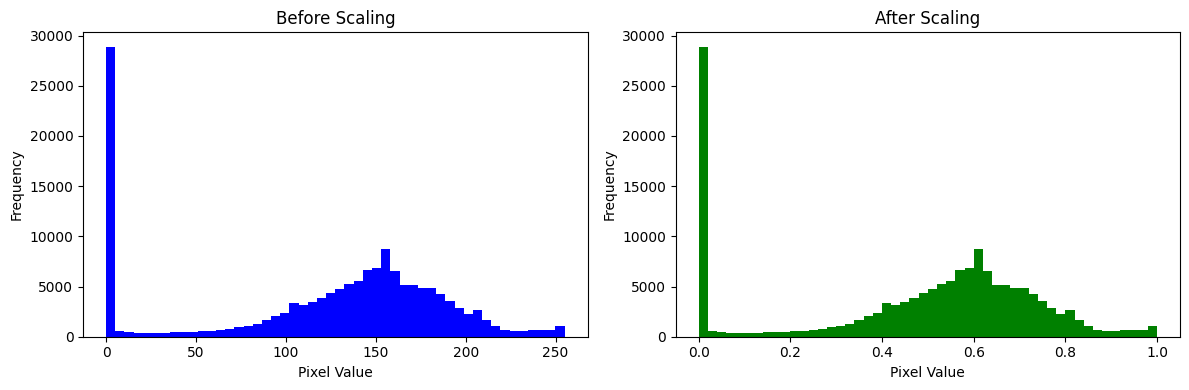

Before Scaling: min=0.0, max=255.0
After Scaling: min=0.0, max=1.0


In [10]:
# Cell 8B
# Load contoh gambar asli
img = image.load_img(example_image_path, target_size=(IMG_SIZE, IMG_SIZE))
x = image.img_to_array(img)

# Histogram sebelum scaling
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(x.ravel(), bins=50, color='blue')
plt.title('Before Scaling')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

# Apply scaling
x_scaled = x / 255.0

# Histogram sesudah scaling
plt.subplot(1,2,2)
plt.hist(x_scaled.ravel(), bins=50, color='green')
plt.title('After Scaling')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Before Scaling: min={x.min()}, max={x.max()}')
print(f'After Scaling: min={x_scaled.min()}, max={x_scaled.max()}')

In [11]:
# Cell 8 Denfisi Model dan Inisialisasi PSO

def create_model(learning_rate, dropout_rate):
    """Membangun arsitektur ResNet50 dengan hyperparameter yang bisa diatur"""
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [13]:
# Cell 10 Generator for training

# Muat hyperparameter dari file
with open('best_hyperparameters.txt', 'r') as f:
    lines = f.readlines()
    best_lr = float(lines[0].split(': ')[1])
    best_dropout = float(lines[1].split(': ')[1])
    best_batch = int(lines[2].split(': ')[1])

final_train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=best_batch,
    class_mode='categorical'
)
print('---------------------------------------------')
final_val_gen = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=best_batch,
    class_mode='categorical'
)
test_generator = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=best_batch,
    class_mode='categorical',
    shuffle=False
)


Found 4408 images belonging to 5 classes.
---------------------------------------------
Found 551 images belonging to 5 classes.
Found 554 images belonging to 5 classes.


In [14]:
# Cell 11 Training Model Final

# Callbacks
callbacks = [
    ModelCheckpoint(
        'pso_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-4,
        verbose=1
    )
]
# Bangun dan latih model final
final_model = create_model(best_lr, best_dropout)

start_time = time.time()

history = final_model.fit(
    final_train_gen,
    steps_per_epoch=final_train_gen.samples // best_batch,
    epochs=EPOCHS,
    validation_data=final_val_gen,
    validation_steps=final_val_gen.samples // best_batch,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

elapsed_time = time.time() - start_time
print(f"\n⏱ Durasi Training Final Model PSO: {elapsed_time:.2f} detik")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.3000 - loss: 2.2082
Epoch 1: val_accuracy improved from None to 0.21818, saving model to pso_model.keras

Epoch 1: finished saving model to pso_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 175s 630ms/step - accuracy: 0.3352 - loss: 1.6627 - val_accuracy: 0.2182 - val_loss: 1.8991 - learning_rate: 0.0035
Epoch 2/30
  1/176 ━━━━━━━━━━━━━━━━━━━━ 48s 276ms/step - accuracy: 0.4000 - loss: 1.2191

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.21818
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4000 - loss: 1.2191 - val_accuracy: 0.2164 - val_loss: 1.8988 - learning_rate: 0.0035
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4143 - loss: 1.2866
Epoch 3: val_accuracy did not improve from 0.21818
176/176 ━━━━━━━━━━━━━━━━━━━━ 74s 418ms/step - accuracy: 0.4636 - loss: 1.1875 - val_accuracy: 0.2182 - val_loss: 2.5033 - learning_rate: 0.0035
Epoch 4/30
  1/176 ━━━━━━━━━━━━━━━━━━━━ 38s 219ms/step - accuracy: 0.5200 - loss: 0.9151
Epoch 4: val_accuracy did not improve from 0.21818
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5200 - loss: 0.9151 - val_accuracy: 0.2182 - val_loss: 2.4979 - learning_rate: 0.0035
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5904 - loss: 0.9705
Epoch 5: val_accuracy did not improve from 0.21818

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0007063999772071839.
176/176 ━━━━━━━━━━━━━━━━━━━

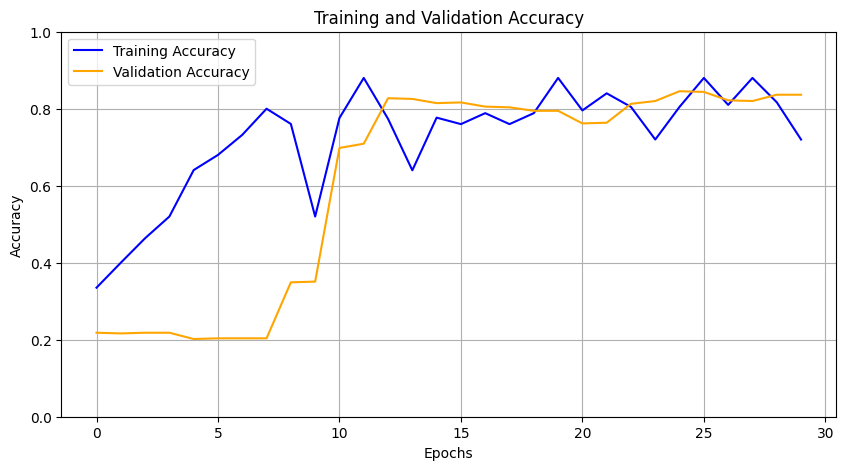

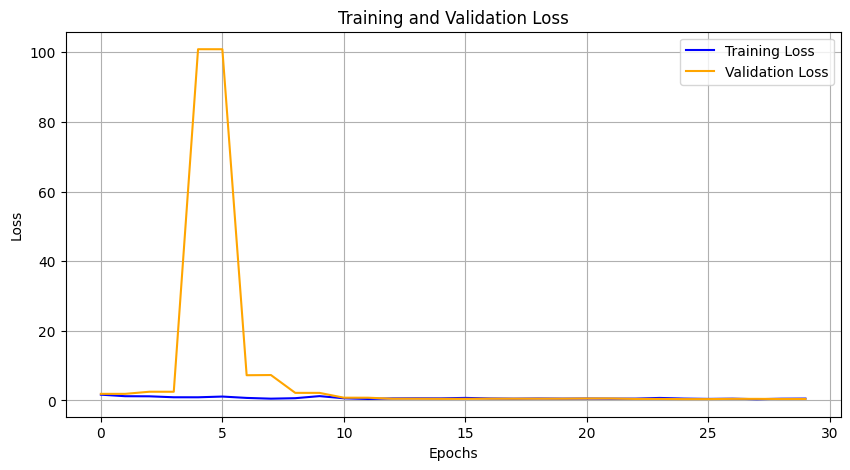

In [15]:
# Cell 11 Plot Akurasi dan Loss
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(accuracy, label='Training Accuracy', color='blue')
plt.plot(val_accuracy, label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)  # Membatasi nilai pada sumbu y antara 0.0 dan 1.0
plt.legend()
plt.grid(True)
plt.savefig('acc.png')
plt.show()

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss.png')
plt.show()

In [16]:
# Cell 12 Test Model using Test Dataset
# After training the model, evaluate on the test set

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=best_batch,
    class_mode='categorical',
    shuffle=False
    )

test_loss, test_accuracy = final_model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")


Found 554 images belonging to 5 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8145 - loss: 0.5004
Test Accuracy: 0.8145454525947571
Test Loss: 0.5004091858863831


In [17]:
# Cell 12 Test Model using Best Test Dataset
# After training the model, evaluate on the test set
from tensorflow.keras.models import load_model

best_model = load_model('pso_model.keras')
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=best_batch,
    class_mode='categorical',
    shuffle=False
    )

test_loss, test_accuracy = final_model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Loss: {test_loss}")


Found 554 images belonging to 5 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8145 - loss: 0.5004
Test Accuracy: 0.8145454525947571
Test Loss: 0.5004091858863831


23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 334ms/step


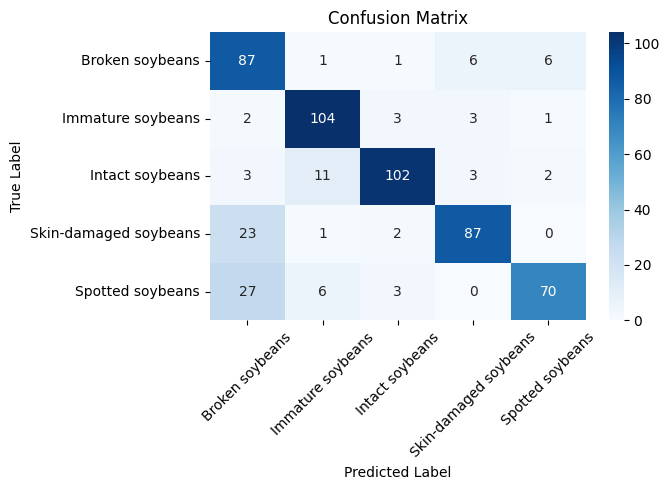


Classification Report:
                       precision    recall  f1-score   support

      Broken soybeans       0.61      0.86      0.72       101
    Immature soybeans       0.85      0.92      0.88       113
      Intact soybeans       0.92      0.84      0.88       121
Skin-damaged soybeans       0.88      0.77      0.82       113
     Spotted soybeans       0.89      0.66      0.76       106

             accuracy                           0.81       554
            macro avg       0.83      0.81      0.81       554
         weighted avg       0.83      0.81      0.81       554


Overall Metrics:
Accuracy: 0.8123
Precision: 0.8336
Recall: 0.8123
F1-Score: 0.8146


In [18]:
# Cell 13 Evaluation
# Get predictions
predictions = final_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Calculate metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

# Calculate overall scores
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


In [19]:
# Cell 15 Save Model
final_model.save('soybean_model.keras')


Saving 14.jpg to 14 (1).jpg


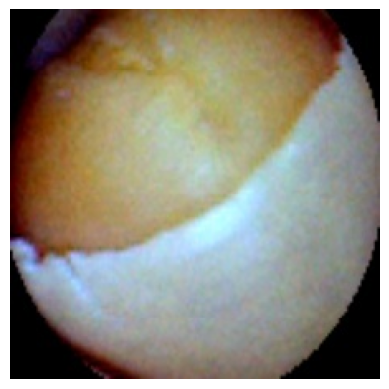

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Hasil Prediksi : Skin-damaged soybeans
Confidence : 96.99%


In [34]:
# Test Model

final_model = load_model('soybean_model.keras')
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = final_model.predict(img_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print(f"Hasil Prediksi : {labels[predicted_class]}")
print(f"Confidence : {confidence*100:.2f}%")